### 0. Drive Connection

In [ ]:
#Give access to Google Drive (access to data)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1. Libraries

In [ ]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Instalación de las librerías necesarias
!pip install matplotlib seaborn numpy pandas xarray rioxarray geopandas rasterio Pillow pyproj scikit-learn pystac-client planetary-computer ydata-profiling tqdm

# Importación de las librerías
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import rasterio
from rasterio import windows, features, warp
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds
from PIL import Image
from pyproj import Proj, Transformer, CRS
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import pystac_client
import planetary_computer as pc
from pystac.extensions.eo import EOExtension as eo
import os
from tqdm import tqdm
from ydata_profiling import ProfileReport

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.7/395.7 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 79.2 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=fc8b65776c6e8ac60073c843063bd68c383bcbc40a263521dd7f199f963d1a31
  Stored in 

# We explored different types of focuses to determine which one is more effective

#DATASETV1

### 2.Load Data (DatasetV1)

In [ ]:
# Training data from csv
path_grounf_df = "/content/drive/MyDrive/DATA CHALLENGE/Training dataset/Training_data_uhi_index_2025-02-18.csv" #Upload the original dataset
ground_df = pd.read_csv(path_grounf_df)
ground_df.head()
#print(ground_df.shape)

,Longitude,Latitude,datetime,UHI Index
0,-73.909167,40.813107,24-07-2021 15:53,1.030289
1,-73.909187,40.813045,24-07-2021 15:53,1.030289
2,-73.909215,40.812978,24-07-2021 15:53,1.023798
3,-73.909242,40.812908,24-07-2021 15:53,1.023798
4,-73.909257,40.812845,24-07-2021 15:53,1.021634


### 3.Extracting band values (code of UHI Experiment Sample Benchmark Notebook V7_2)

In [ ]:
# Extracts satellite band values from a GeoTIFF based on coordinates from a csv file and returns them in a DataFrame.

def map_satellite_data(tiff_path, csv_path):

    # Load the GeoTIFF data
    data = rxr.open_rasterio(tiff_path)
    tiff_crs = data.rio.crs

    # Read the Excel file using pandas
    df = pd.read_csv(csv_path)
    latitudes = df['Latitude'].values
    longitudes = df['Longitude'].values

    #Convert lat/long to the GeoTIFF's CRS
    # Create a Proj object for EPSG:4326 (WGS84 - lat/long) and the GeoTIFF's CRS
    proj_wgs84 = Proj(init='epsg:4326')  # EPSG:4326 is the common lat/long CRS
    proj_tiff = Proj(tiff_crs)

    # Create a transformer object
    transformer = Transformer.from_proj(proj_wgs84, proj_tiff)

    B01_values = []
    B04_values = []
    B06_values = []
    B08_values = []

# Iterate over the latitudes and longitudes, and extract the corresponding band values
    for lat, lon in tqdm(zip(latitudes, longitudes), total=len(latitudes), desc="Mapping values"):
    # Assuming the correct dimensions are 'y' and 'x' (replace these with actual names from data.coords)

        B01_value = data.sel(x=lon, y=lat,  band=1, method="nearest").values
        B01_values.append(B01_value)

        B04_value = data.sel(x=lon, y=lat, band=2, method="nearest").values
        B04_values.append(B04_value)

        B06_value = data.sel(x=lon, y=lat, band=3, method="nearest").values
        B06_values.append(B06_value)

        B08_value = data.sel(x=lon, y=lat, band=4, method="nearest").values
        B08_values.append(B08_value)

    # Create a DataFrame with the band values
    # Create a DataFrame to store the band values
    df = pd.DataFrame()
    df['B01'] = B01_values
    df['B04'] = B04_values
    df['B06'] = B06_values
    df['B08'] = B08_values

    return df

In [ ]:
# Mapping satellite data with training data.
path_sample_tiff = "/content/drive/MyDrive/DATA CHALLENGE/S2_sample.tiff"
band_data = map_satellite_data(path_sample_tiff, path_grounf_df)
band_data.head(5)

Mapping values: 100%|██████████| 11229/11229 [01:34<00:00, 118.48it/s]


,B01,B04,B06,B08
0,846.0,1036.0,1502.0,1906.0
1,846.0,1036.0,1502.0,1906.0
2,846.0,709.0,1668.0,2190.0
3,846.0,657.0,1668.0,2182.0
4,846.0,745.0,1728.0,2112.0


NDVI INDEX Calculation

In [ ]:
band_data['NDVI'] = (band_data['B08'] - band_data['B04']) / (band_data['B08'] + band_data['B04'])
band_data['NDVI'] = band_data['NDVI'].replace([np.inf, -np.inf], np.nan)

In [ ]:
# Combine two datasets vertically (along columns) using pandas concat function.
def combine_two_datasets(dataset1,dataset2):
    '''
    Returns a  vertically concatenated dataset.
    Attributes:
    dataset1 - Dataset 1 to be combined
    dataset2 - Dataset 2 to be combined
    '''

    data = pd.concat([dataset1,dataset2], axis=1)
    return data

In [ ]:
# Combining ground data and band data into a single dataset.
uhi_data = combine_two_datasets(ground_df,band_data)
uhi_data.head()

,Longitude,Latitude,datetime,UHI Index,B01,B04,B06,B08,NDVI
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,846.0,1036.0,1502.0,1906.0,0.295717
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,846.0,1036.0,1502.0,1906.0,0.295717
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,846.0,709.0,1668.0,2190.0,0.510866
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,846.0,657.0,1668.0,2182.0,0.537161
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,846.0,745.0,1728.0,2112.0,0.478474


### Data analysis

In [126]:
def analyze_dataset(df, df_name="DataFrame"):
    """
    Perform an exploratory data analysis:
    - Dimensions, initial view (head)
    - Info (column types)
    - Null and duplicate values
    - Statistical description
    - Correlation and heatmap (only for numerical columns)
    - Histograms and boxplots of numerical variables
    """
    print(f"\n========== {df_name} ==========")
    print(f"Shape (filas, columnas): {df.shape}\n")

    # Display the first rows
    print(f"HEAD of {df_name}:")
    display(df.head())

    # Kind of data
    print(f"\nINFO of {df_name}:")
    display(df.info()) #Filas,columnas,tipos de dato, no nulos y memoria del df

    # null count
    print(f"\nNull values in {df_name}:")
    print(df.isna().sum())

    # Duplicates
    duplicates_count = df.duplicated().sum()
    print(f"\nDuplicate data in {df_name}: {duplicates_count}")

    # Statistical description
    print(f"\nSTATISTICAL DESCRIPTION of {df_name}:")
    display(df.describe())

    # Select only numerical columns for correlation and graphs
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    if len(numeric_cols) > 1:
        # Correlation heatmap
        corr_matrix = df[numeric_cols].corr()
        print(f"\nCORRELATION MATRIX (numerical) in{df_name}:")
        display(corr_matrix)

        plt.figure(figsize=(10, 7))
        sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
        plt.title(f"Correlation heatmap - {df_name}")
        plt.show()

        # Histograma
        df[numeric_cols].hist(figsize=(12, 8), bins=25, edgecolor='black')
        plt.suptitle(f"Histograms of numerical variables - {df_name}", fontsize=16)
        plt.show()

        # Boxplots para detección de outliers
        plt.figure(figsize=(12, 8))
        df[numeric_cols].plot(kind='box', subplots=True, layout=(1, len(numeric_cols)),
                              sharex=False, sharey=False, figsize=(15,5))
        plt.suptitle(f"Boxplots of numerical variables. - {df_name}", fontsize=16)
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nThere are not enough numerical columns for correlation in {df_name}.")


Extra preparation

In [127]:
for col in uhi_data.columns:
    if uhi_data[col].apply(lambda x: isinstance(x, np.ndarray)).any():
        uhi_data[col] = uhi_data[col].apply(lambda x: x.item() if isinstance(x, np.ndarray) and x.ndim == 0 else x) # Convert 0-d array to a scalar
#print(f'Duplicados en uhi_data: {uhi_data.duplicated().sum()}')


========== UHI_DATA ==========
Shape (filas, columnas): (11229, 9)

HEAD of UHI_DATA:


,Longitude,Latitude,datetime,UHI Index,B01,B04,B06,B08,NDVI
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,846.0,1036.0,1502.0,1906.0,0.295717
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,846.0,1036.0,1502.0,1906.0,0.295717
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,846.0,709.0,1668.0,2190.0,0.510866
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,846.0,657.0,1668.0,2182.0,0.537161
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,846.0,745.0,1728.0,2112.0,0.478474



INFO of UHI_DATA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Longitude  11229 non-null  float64
 1   Latitude   11229 non-null  float64
 2   datetime   11229 non-null  object 
 3   UHI Index  11229 non-null  float64
 4   B01        11229 non-null  float64
 5   B04        11229 non-null  float64
 6   B06        11229 non-null  float64
 7   B08        11229 non-null  float64
 8   NDVI       11229 non-null  float64
dtypes: float64(8), object(1)
memory usage: 789.7+ KB


None


Null values in UHI_DATA:
Longitude    0
Latitude     0
datetime     0
UHI Index    0
B01          0
B04          0
B06          0
B08          0
NDVI         0
dtype: int64

Duplicate data in UHI_DATA: 0

STATISTICAL DESCRIPTION of UHI_DATA:


,Longitude,Latitude,UHI Index,B01,B04,B06,B08,NDVI
count,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000,11229.000000
mean,-73.933927,40.808800,1.000001,1577.434233,1639.084691,2150.186036,2225.908273,0.181637
std,0.028253,0.023171,0.016238,1510.100390,1456.841224,1380.281893,1425.736087,0.202704
min,-73.994457,40.758792,0.956122,265.000000,167.000000,245.000000,210.000000,-0.381555
25%,-73.955703,40.790905,0.988577,883.000000,828.000000,1484.000000,1474.000000,0.044431
50%,-73.932968,40.810688,1.000237,1173.000000,1276.000000,1884.000000,1928.000000,0.106618
75%,-73.909647,40.824515,1.011176,1554.000000,1798.000000,2355.000000,2586.000000,0.258089
max,-73.879458,40.859497,1.046036,12280.000000,12736.000000,12682.000000,12992.000000,0.889549



CORRELATION MATRIX (numerical) inUHI_DATA:


,Longitude,Latitude,UHI Index,B01,B04,B06,B08,NDVI
Longitude,1.000000,0.642699,0.380995,0.368769,0.317290,0.258937,0.203355,-0.321277
Latitude,0.642699,1.000000,0.446435,0.157025,0.133069,0.104960,0.080968,-0.144193
UHI Index,0.380995,0.446435,1.000000,0.193179,0.175350,0.117021,0.082083,-0.254888
B01,0.368769,0.157025,0.193179,1.000000,0.913150,0.893580,0.829613,-0.315979
B04,0.317290,0.133069,0.175350,0.913150,1.000000,0.915417,0.892224,-0.410457
B06,0.258937,0.104960,0.117021,0.893580,0.915417,1.000000,0.949094,-0.103072
B08,0.203355,0.080968,0.082083,0.829613,0.892224,0.949094,1.000000,0.020758
NDVI,-0.321277,-0.144193,-0.254888,-0.315979,-0.410457,-0.103072,0.020758,1.000000


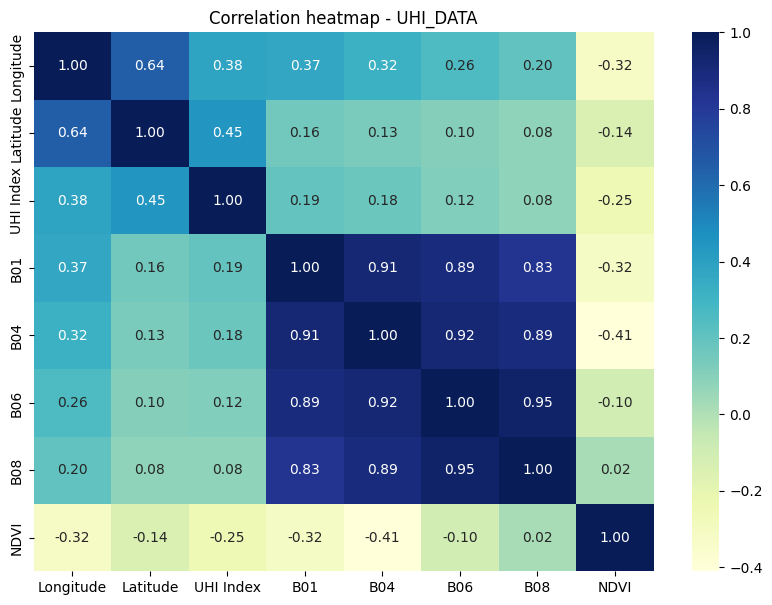

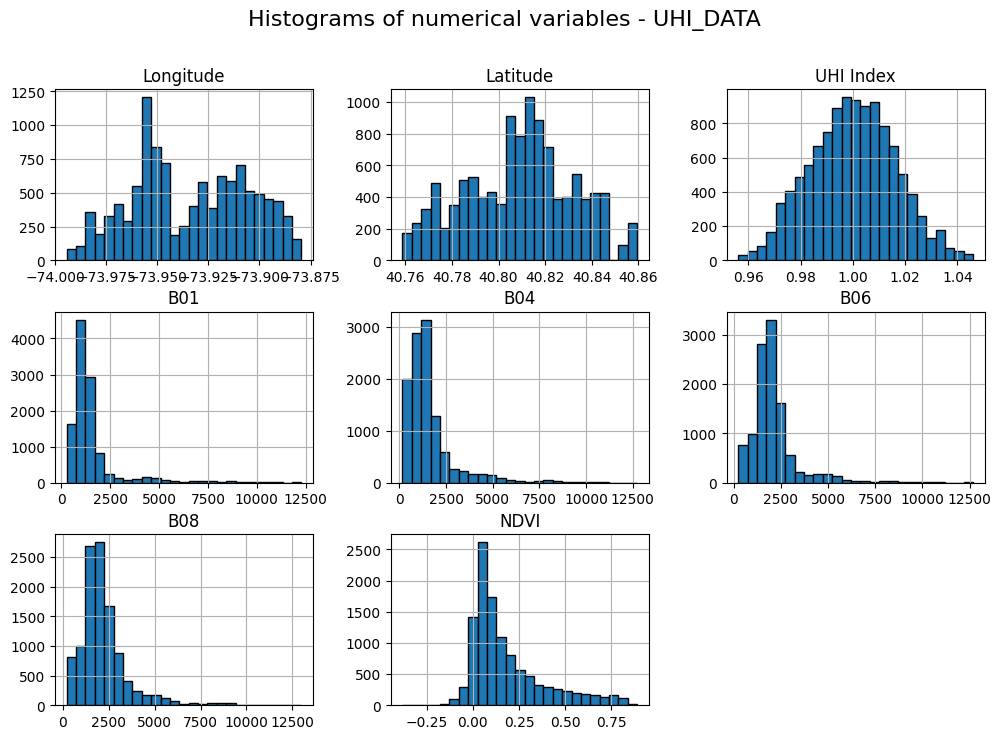

<Figure size 1200x800 with 0 Axes>

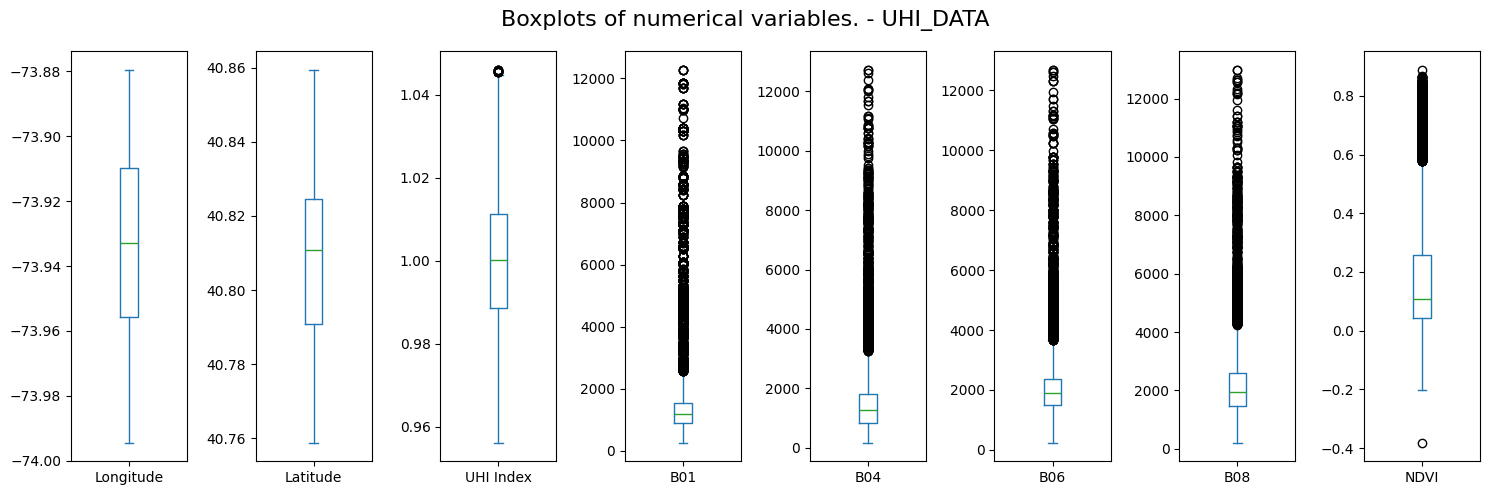

In [128]:
#UHI Data Analysis
analyze_dataset(uhi_data, "UHI_DATA")

### Model preparation

In [129]:
features = ["B01", "B04", "B06", "B08", "NDVI"]
target = "UHI Index"

X = uhi_data[features]
y = uhi_data[target]

print("Size X:", X.shape)
print("Size y:", y.shape)

Size X: (11229, 5)
Size y: (11229,)


Data split

In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training Size:", X_train.shape, y_train.shape)
print("Test Size:", X_test.shape, y_test.shape)

Training Size: (8983, 5) (8983,)
Test Size: (2246, 5) (2246,)


Training

In [131]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1 #All available cores
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

Insample Evaluation

In [132]:
insample_predictions = rf_model.predict(X_train)

Y_train = y_train.tolist()
r2_score(Y_train, insample_predictions)

0.47088872812843396

Test data evaluation

In [133]:
outsample_predictions = rf_model.predict(X_test)

Y_test = y_test.tolist()
r2_score(Y_test, outsample_predictions)

0.3475587407269768

#DATASETV2

### Load Data (DatasetV2)

In [ ]:
#DATASET HYPERLOCAL
path_hyperlocal = "/content/drive/MyDrive/DATA CHALLENGE/Hyperlocal_Temperature_Monitoring_20250225.csv"
df_raw2 = pd.read_csv(path_hyperlocal, engine="c")
print("Shape hyperlocal_df:", df_raw2.shape)
display(df_raw2.head())

Shape hyperlocal_df: (1048575, 10)


,Sensor.ID,AirTemp,Day,Hour,Latitude,Longitude,Year,Install.Type,Borough,ntacode
0,Bk-BR_01,71.189000,06/15/2018,1,40.666205,-73.91691,2018,Street Tree,Brooklyn,BK81
1,Bk-BR_01,70.243333,06/15/2018,2,40.666205,-73.91691,2018,Street Tree,Brooklyn,BK81
2,Bk-BR_01,69.392667,06/15/2018,3,40.666205,-73.91691,2018,Street Tree,Brooklyn,BK81
3,Bk-BR_01,68.263167,06/15/2018,4,40.666205,-73.91691,2018,Street Tree,Brooklyn,BK81
4,Bk-BR_01,67.114000,06/15/2018,5,40.666205,-73.91691,2018,Street Tree,Brooklyn,BK81


In [ ]:
#***********PREPARE DATASET 'Hyperlocal_temperature' to merge with the source dataset**************
#UHI Index calculation
mean_temp = df_raw2["AirTemp"].mean()

#Create the UHI INDEX columns
df_raw2["UHI Index"] = df_raw2["AirTemp"] / mean_temp

#Filter only values from the Bronx and Manhattan
df_raw2 = df_raw2[df_raw2["Borough"].isin(["Bronx","Manhattan"])]

#Combine: 'Day'+ 'Hour' to obtain column 'datetime'
df_raw2["datetime"] = pd.to_datetime(df_raw2["Day"] + " " + df_raw2["Hour"].astype(str) + ":00", format= "%m/%d/%Y %H:%M")
df_raw2["datetime"] = df_raw2["datetime"].dt.strftime("%m/%d/%Y %H:%M") #Se formatea para que solo se muestren minutos (se formatea sin segundos)

#Save only the necessary columns
#*List of columns to use
columns_use = ["Longitude", "Latitude","datetime","UHI Index", "Borough","ntacode"]
#New dataframe with specific data
df_raw3 = df_raw2[columns_use]

df_raw3.head(5)
print(df_raw3.shape)

(563068, 6)


In [ ]:
#DATASETS union
df_dataset_v2 = pd.concat([ground_df, df_raw3], ignore_index=True)
df_dataset_v2.head()
print(df_dataset_v2.shape)

df_dataset_v2.to_csv('/content/drive/MyDrive/DATA CHALLENGE/Dataset_V2.csv', index=False)
display(df_dataset_v2.head())
#There are blanks, and they come from the 'Hyperlocal...' dataset

(574297, 6)


,Longitude,Latitude,datetime,UHI Index,Borough,ntacode
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,NaN,NaN
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,NaN,NaN
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,NaN,NaN
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,NaN,NaN
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,NaN,NaN


Band extraction (1 hour aprox)

In [ ]:
# Mapping satellite data with training data.
path_df2 = "/content/drive/MyDrive/DATA CHALLENGE/Dataset_V2.csv"
path_sample_tiff = "/content/drive/MyDrive/DATA CHALLENGE/S2_sample.tiff"
band_dataV2 = map_satellite_data(path_sample_tiff, path_df2)
band_dataV2.head(5)

In [ ]:
# Calculate NDVI (Normalized Difference Vegetation Index) and handle division by zero by replacing infinities with NaN.
band_dataV2['NDVI'] = (band_dataV2['B08'] - band_dataV2['B04']) / (band_dataV2['B08'] + band_dataV2['B04'])
band_dataV2['NDVI'] = band_dataV2['NDVI'].replace([np.inf, -np.inf], np.nan)

In [ ]:
# Combining ground data and final data into a single dataset.
uhi_dataV2 = combine_two_datasets(df_dataset_v2,band_dataV2)

#Reorder columns
uhi_dataV2 = uhi_dataV2[["Latitude", "Longitude", "UHI Index", "B01", "B04", "B06", "B08", "NDVI","Borough","ntacode"]]
uhi_dataV2.head()

In [ ]:
output_path2 = "/content/drive/MyDrive/DATA CHALLENGE/uhi_dataV2.csv"
uhi_dataV2.to_csv(output_path2, index=False)

uhi_dataV2 = uhi_dataV2.fillna(1) #Necessary to proceed with the analysis, as the values being added are in UNUSED columns

output_path3 = "/content/drive/MyDrive/DATA CHALLENGE/uhi_dataV2_1.csv"
uhi_dataV2.to_csv(output_path3, index=False)

NameError: name 'uhi_dataV2' is not defined

In [ ]:
uhi_dataV2 = pd.read_csv("/content/drive/MyDrive/DATA CHALLENGE/uhi_dataV2_1.csv")
display(uhi_dataV2.head())

,Latitude,Longitude,UHI Index,B01,B04,B06,B08,NDVI,Borough,ntacode
0,40.813107,-73.909167,1.030289,846.0,1036.0,1502.0,1906.0,0.295717,1,1
1,40.813045,-73.909187,1.030289,846.0,1036.0,1502.0,1906.0,0.295717,1,1
2,40.812978,-73.909215,1.023798,846.0,709.0,1668.0,2190.0,0.510866,1,1
3,40.812908,-73.909242,1.023798,846.0,657.0,1668.0,2182.0,0.537161,1,1
4,40.812845,-73.909257,1.021634,846.0,745.0,1728.0,2112.0,0.478474,1,1


### Data analysis

Extra preparation

In [ ]:
for col in uhi_dataV2.columns:
    if uhi_dataV2[col].apply(lambda x: isinstance(x, np.ndarray)).any():
        uhi_dataV2[col] = uhi_dataV2[col].apply(lambda x: x.item() if isinstance(x, np.ndarray) and x.ndim == 0 else x) # Convert 0-d array to a scalar
print(f'Duplicados en uhi_data: {uhi_dataV2.duplicated().sum()}')

Duplicados en uhi_data: 26085



========== UHI_DATA ==========
Shape (filas, columnas): (574297, 10)

HEAD de UHI_DATA:


,Latitude,Longitude,UHI Index,B01,B04,B06,B08,NDVI,Borough,ntacode
0,40.813107,-73.909167,1.030289,846.0,1036.0,1502.0,1906.0,0.295717,1,1
1,40.813045,-73.909187,1.030289,846.0,1036.0,1502.0,1906.0,0.295717,1,1
2,40.812978,-73.909215,1.023798,846.0,709.0,1668.0,2190.0,0.510866,1,1
3,40.812908,-73.909242,1.023798,846.0,657.0,1668.0,2182.0,0.537161,1,1
4,40.812845,-73.909257,1.021634,846.0,745.0,1728.0,2112.0,0.478474,1,1



INFO de UHI_DATA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 574297 entries, 0 to 574296
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Latitude   574297 non-null  float64
 1   Longitude  574297 non-null  float64
 2   UHI Index  574297 non-null  float64
 3   B01        574297 non-null  float64
 4   B04        574297 non-null  float64
 5   B06        574297 non-null  float64
 6   B08        574297 non-null  float64
 7   NDVI       574297 non-null  float64
 8   Borough    574297 non-null  object 
 9   ntacode    574297 non-null  object 
dtypes: float64(8), object(2)
memory usage: 43.8+ MB


None


Valores nulos en UHI_DATA:
Latitude     0
Longitude    0
UHI Index    0
B01          0
B04          0
B06          0
B08          0
NDVI         0
Borough      0
ntacode      0
dtype: int64

Registros duplicados en UHI_DATA: 26085

DESCRIPCIÓN ESTADÍSTICA de UHI_DATA:


,Latitude,Longitude,UHI Index,B01,B04,B06,B08,NDVI
count,574297.000000,574297.000000,574297.000000,574297.000000,574297.000000,574297.000000,574297.000000,574297.000000
mean,40.825203,-73.908558,1.002066,1557.332810,1584.825521,2139.080119,2186.020592,0.183726
std,0.031400,0.035087,0.117392,813.996513,1003.750011,892.828452,952.999707,0.163292
min,40.758792,-73.994457,0.604088,265.000000,167.000000,245.000000,210.000000,-0.381555
25%,40.803959,-73.945200,0.933871,1174.000000,998.000000,1753.000000,1730.000000,0.055588
50%,40.810314,-73.911802,0.995790,1405.000000,1312.000000,1986.000000,2008.000000,0.142650
75%,40.853830,-73.885588,1.078420,1703.000000,1926.000000,2547.000000,2654.000000,0.294039
max,40.884616,-73.844703,1.445664,12280.000000,12736.000000,12682.000000,12992.000000,0.889549



MATRIZ DE CORRELACIÓN (numéricas) en UHI_DATA:


,Latitude,Longitude,UHI Index,B01,B04,B06,B08,NDVI
Latitude,1.000000,0.771045,-0.051615,-0.117259,-0.116021,0.060877,0.094129,0.362958
Longitude,0.771045,1.000000,-0.036450,0.255204,0.106894,0.282121,0.256661,0.192608
UHI Index,-0.051615,-0.036450,1.000000,0.028101,0.029819,0.010445,0.004904,-0.052048
B01,-0.117259,0.255204,0.028101,1.000000,0.733213,0.770164,0.643073,-0.352863
B04,-0.116021,0.106894,0.029819,0.733213,1.000000,0.831281,0.856678,-0.525009
B06,0.060877,0.282121,0.010445,0.770164,0.831281,1.000000,0.875079,-0.191450
B08,0.094129,0.256661,0.004904,0.643073,0.856678,0.875079,1.000000,-0.035709
NDVI,0.362958,0.192608,-0.052048,-0.352863,-0.525009,-0.191450,-0.035709,1.000000


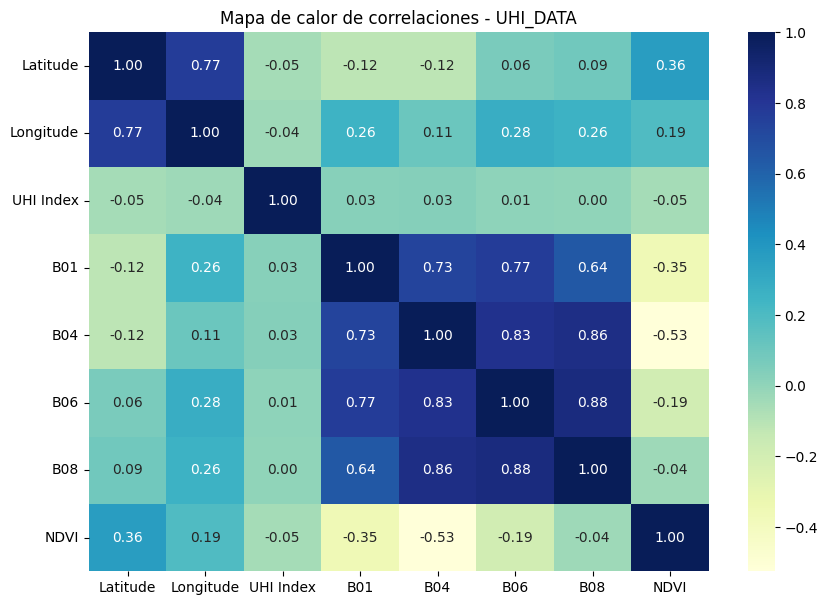

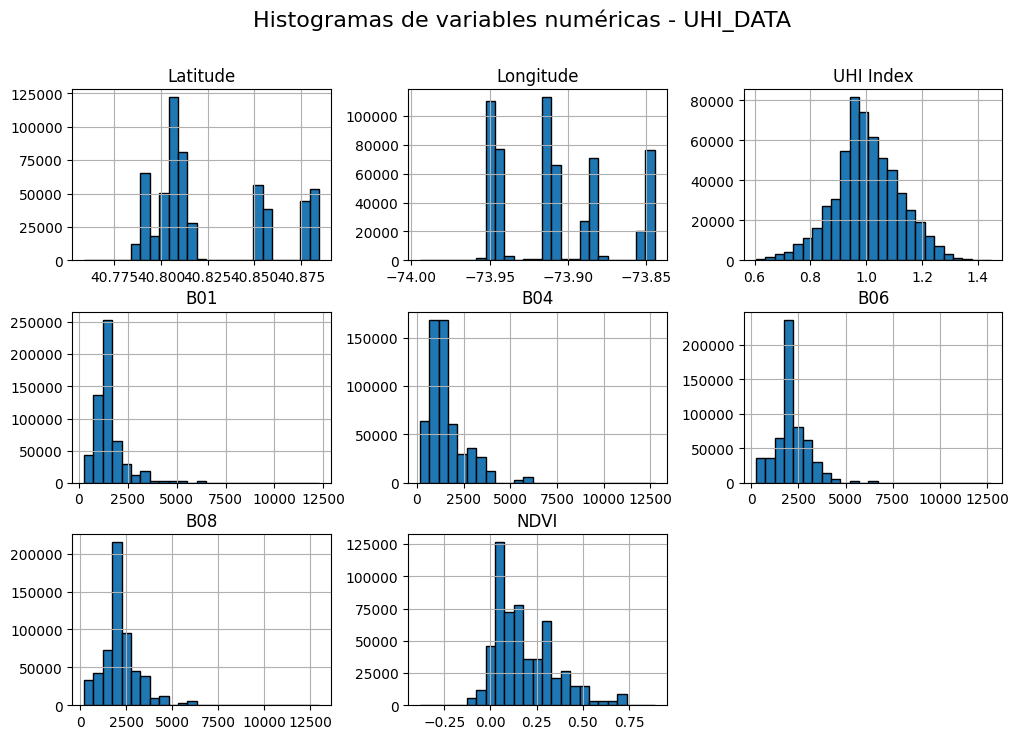

<Figure size 1200x800 with 0 Axes>

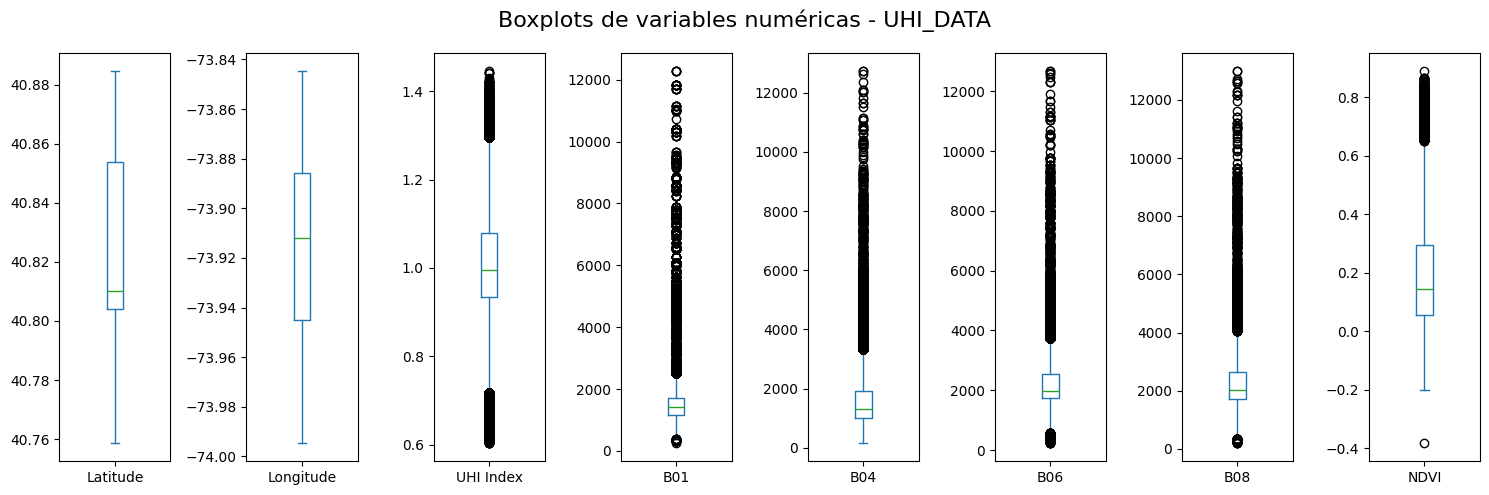

In [ ]:
#UHI Data + bands Analysis
analyze_dataset(uhi_dataV2, "UHI_DATA")

### Model preparation

In [ ]:
features2 = ["B01", "B04", "B06", "B08", "NDVI"]
target2 = "UHI Index"

X_2 = uhi_dataV2[features2]
y_2 = uhi_dataV2[target2]

print("X Size:", X_2.shape)
print("y Size:", y_2.shape)

Tamaño X: (574297, 5)
Tamaño y: (574297,)


Data split

In [ ]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_2, y_2,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training Size:", X_train_2.shape, y_train_2.shape)
print("Test Size:", X_test_2.shape, y_test_2.shape)

Tamaño Training: (459437, 5) (459437,)
Tamaño Test: (114860, 5) (114860,)


Training

In [ ]:
rf_model_2 = RandomForestRegressor(
    n_estimators=100,
    max_depth=None, #Allow trees to grow completely (though overfitting may occur)
    random_state=42,
    n_jobs=-1 #All available cores
)

rf_model_2.fit(X_train_2, y_train_2)

RandomForestRegressor(n_jobs=-1, random_state=42)

Insample evaluation

In [ ]:
insample_predictions2 = rf_model_2.predict(X_train_2)

Y_train_2 = y_train_2.values.tolist()
r2_score(Y_train_2, insample_predictions2)

0.00818754674965283

Test data evaluation

In [ ]:
outsample_predictions2 = rf_model_2.predict(X_test_2)

Y_test_2 = y_test_2.values.tolist()
r2_score(Y_test_2, outsample_predictions2)

0.007530742632740783

#DATASETV1 with extra features

### Extracting band values

In [134]:
# Extracts satellite band values from a GeoTIFF based on coordinates from a csv file and returns them in a DataFrame.
def map_satellite_data_v2(tiff_path, csv_path):

    # Load the GeoTIFF data
    data = rxr.open_rasterio(tiff_path)
    tiff_crs = data.rio.crs

    # Read the Excel file using pandas
    df = pd.read_csv(csv_path)
    latitudes = df['Latitude'].values
    longitudes = df['Longitude'].values

    # 3. Convert lat/long to the GeoTIFF's CRS
    # Create a Proj object for EPSG:4326 (WGS84 - lat/long) and the GeoTIFF's CRS
    proj_wgs84 = Proj(init='epsg:4326')  # EPSG:4326 is the common lat/long CRS
    proj_tiff = Proj(tiff_crs)

    # Create a transformer object
    transformer = Transformer.from_proj(proj_wgs84, proj_tiff)

    B01_values = []
    B02_values = []
    B03_values = []
    B04_values = []
    B05_values = []
    B06_values = []
    B07_values = []
    B08_values = []
    B8A_values = []
    B11_values = []
    B12_values = []

    # Extract time values from the GeoTIFF
    #time_values = data['time'].values  # Asegúrate de que 'time' sea el nombre correcto de la dimensión

    #time_values = [None] * len(latitudes)
    #Iterate over the latitudes and longitudes, and extract the corresponding band values
    for lat, lon in tqdm(zip(latitudes, longitudes), total=len(latitudes), desc="Mapping values"):
    # Assuming the correct dimensions are 'y' and 'x' (replace these with actual names from data.coords)
        B01_value = data.sel(x=lon, y=lat, band=1, method="nearest").values
        B01_values.append(B01_value)

        B02_value = data.sel(x=lon, y=lat, band=2, method="nearest").values
        B02_values.append(B02_value)

        B03_value = data.sel(x=lon, y=lat, band=3, method="nearest").values
        B03_values.append(B03_value)

        B04_value = data.sel(x=lon, y=lat, band=4, method="nearest").values
        B04_values.append(B04_value)

        B05_value = data.sel(x=lon, y=lat, band=5, method="nearest").values
        B05_values.append(B05_value)

        B06_value = data.sel(x=lon, y=lat, band=6, method="nearest").values
        B06_values.append(B06_value)

        B07_value = data.sel(x=lon, y=lat, band=7, method="nearest").values
        B07_values.append(B07_value)

        B08_value = data.sel(x=lon, y=lat, band=8, method="nearest").values
        B08_values.append(B08_value)

        B8A_value = data.sel(x=lon, y=lat, band=9, method="nearest").values
        B8A_values.append(B8A_value)

        B11_value = data.sel(x=lon, y=lat, band=10, method="nearest").values
        B11_values.append(B11_value)

        B12_value = data.sel(x=lon, y=lat, band=11, method="nearest").values
        B12_values.append(B12_value)


    # Create a DataFrame with the band values
    # Create a DataFrame to store the band values
    df['B01'] = B01_values
    df['B02'] = B02_values
    df['B03'] = B03_values
    df['B04'] = B04_values
    df['B05'] = B05_values
    df['B06'] = B06_values
    df['B07'] = B07_values
    df['B08'] = B08_values
    df['B8A'] = B8A_values
    df['B11'] = B11_values
    df['B12'] = B12_values

    #df['time'] = time_values

    return df

In [ ]:
# Mapping satellite data with training data.
path_sample_tiff = "/content/drive/MyDrive/DATA CHALLENGE/S2_sample.tiff"
band_data_plus = map_satellite_data_v2(path_sample_tiff, path_grounf_df)
band_data_plus.head(5)

Mapping values: 100%|██████████| 11229/11229 [03:55<00:00, 47.65it/s]


,Longitude,Latitude,datetime,UHI Index,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,846.0,1036.0,1502.0,1906.0,1906.0,1906.0,1906.0,1906.0,1906.0,1906.0,1906.0
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,846.0,1036.0,1502.0,1906.0,1906.0,1906.0,1906.0,1906.0,1906.0,1906.0,1906.0
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,846.0,709.0,1668.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,846.0,657.0,1668.0,2182.0,2182.0,2182.0,2182.0,2182.0,2182.0,2182.0,2182.0
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,846.0,745.0,1728.0,2112.0,2112.0,2112.0,2112.0,2112.0,2112.0,2112.0,2112.0


In [135]:
# Calculate NDVI (Normalized Difference Vegetation Index) and handle division by zero by replacing infinities with NaN.
band_data_plus['NDVI'] = (band_data_plus['B08'] - band_data_plus['B04']) / (band_data_plus['B08'] + band_data_plus['B04'])
band_data_plus['NDVI'] = band_data_plus['NDVI'].replace([np.inf, -np.inf], np.nan)

# Calculate NDBI
band_data_plus['NDBI'] = (band_data_plus['B11'] - band_data_plus['B08']) / (band_data_plus['B11'] + band_data_plus['B08'])
band_data_plus['NDBI'] = band_data_plus['NDBI'].replace([np.inf, -np.inf], np.nan)

# Calculate NDWI
band_data_plus['NDWI'] = (band_data_plus['B03'] - band_data_plus['B08']) / (band_data_plus['B03'] + band_data_plus['B08'])
band_data_plus['NDWI'] = band_data_plus['NDWI'].replace([np.inf, -np.inf], np.nan)

# Display the first rows of the DataFrame with the calculated indices
print(band_data_plus[['NDVI', 'NDBI', 'NDWI']].head())

   NDVI  NDBI      NDWI
0   0.0   0.0 -0.118545
1   0.0   0.0 -0.118545
2   0.0   0.0 -0.135303
3   0.0   0.0 -0.133506
4   0.0   0.0 -0.100000


*******This block is UNUSED

In [136]:
# Calculate NDVI (Normalized Difference Vegetation Index) and handle division by zero by replacing infinities with NaN.
# Calculate the median along each column
median_B08 = band_data_plus['B08'].median()
median_B04 = band_data_plus['B04'].median()
median_B11 = band_data_plus['B11'].median()
median_B03 = band_data_plus['B03'].median()

# Calculate NDVI using the median
band_data_plus['NDVI'] = (median_B08 - median_B04) / (median_B08 + median_B04)
band_data_plus['NDVI'] = band_data_plus['NDVI'].replace([np.inf, -np.inf], np.nan)

# Calculate NDBI using the median
band_data_plus['NDBI'] = (median_B11 - median_B08) / (median_B11 + median_B08)
band_data_plus['NDBI'] = band_data_plus['NDBI'].replace([np.inf, -np.inf], np.nan)

# Calculate NDWI using the median
band_data_plus['NDWI'] = (median_B03 - median_B08) / (median_B03 + median_B08)
band_data_plus['NDWI'] = band_data_plus['NDWI'].replace([np.inf, -np.inf], np.nan)

# Display the first few rows of the DataFrame with the calculated indices
print(band_data_plus[['NDVI', 'NDBI', 'NDWI']].head())

TypeError: Cannot convert [array(1906.) array(1906.) array(2190.) ... array(2900.) array(2900.)
 array(3338.)] to numeric

************************

In [137]:
ground_df.head()

,Longitude,Latitude,datetime,UHI Index
0,-73.909167,40.813107,24-07-2021 15:53,1.030289
1,-73.909187,40.813045,24-07-2021 15:53,1.030289
2,-73.909215,40.812978,24-07-2021 15:53,1.023798
3,-73.909242,40.812908,24-07-2021 15:53,1.023798
4,-73.909257,40.812845,24-07-2021 15:53,1.021634


In [138]:
band_data_plus.head()

,Longitude,Latitude,datetime,UHI Index,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12,NDVI,NDBI,NDWI
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,846.0,1036.0,1502.0,1906.0,1906.0,1906.0,1906.0,1906.0,1906.0,1906.0,1906.0,0.0,0.0,-0.118545
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,846.0,1036.0,1502.0,1906.0,1906.0,1906.0,1906.0,1906.0,1906.0,1906.0,1906.0,0.0,0.0,-0.118545
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,846.0,709.0,1668.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,0.0,0.0,-0.135303
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,846.0,657.0,1668.0,2182.0,2182.0,2182.0,2182.0,2182.0,2182.0,2182.0,2182.0,0.0,0.0,-0.133506
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,846.0,745.0,1728.0,2112.0,2112.0,2112.0,2112.0,2112.0,2112.0,2112.0,2112.0,0.0,0.0,-0.100000


Extract the data to analyze it

In [122]:
band_data_plus.to_csv('/content/drive/MyDrive/DATA CHALLENGE/band_data_plus.csv', index=False)

### Model preparation

In [139]:
features3 = ["B01","B02","B03", "B04","B05", "B06","B07", "B08","B8A","B11","B12", "NDVI","NDBI"]
#We observe that the NDWI index affects the training results, therefore, we omit that index in this part
#features4 = ["B01","B02","B03", "B04","B05", "B06","B07", "B08","B8A","B11","B12", "NDVI","NDBI","NDWI"]
target3 = "UHI Index"

X_3 = band_data_plus[features3]
y_3 = band_data_plus[target3]

print("X Size:", X_3.shape)
print("y Size:", y_3.shape)

X Size: (11229, 13)
y Size: (11229,)


Data split

In [140]:
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X_3, y_3,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training Size:", X_train_3.shape, y_train_3.shape)
print("Test Size:", X_test_3.shape, y_test_3.shape)

Training Size: (8983, 13) (8983,)
Test Size: (2246, 13) (2246,)


Training

In [141]:
sc = StandardScaler()
X_train_3 = sc.fit_transform(X_train_3)
X_test_3 = sc.transform(X_test_3)

In [142]:
rf_model_3 = RandomForestRegressor(
    n_estimators=100,
    max_depth=None, #Allow trees to grow completely (although overfitting may occur)
    random_state=42,
    n_jobs=-1 #All available cores
)

rf_model_3.fit(X_train_3, y_train_3)

RandomForestRegressor(n_jobs=-1, random_state=42)

Insample evaluation

In [143]:
insample_predictions3 = rf_model_3.predict(X_train_3)

Y_train_3 = y_train_3.values.tolist()
r2_score(Y_train_3, insample_predictions3)

0.9406787378592423

Test data evaluation

In [144]:
outsample_predictions3 = rf_model_3.predict(X_test_3)

Y_test_3 = y_test_3.values.tolist()
r2_score(Y_test_3, outsample_predictions3)

0.6029502533458367

# Submission

In [145]:
#Reading the coordinates for the submission
test_file = pd.read_csv('/content/drive/MyDrive/DATA CHALLENGE/Submission/Submission_template_UHI2025-v2.csv')
test_file.head()

,Longitude,Latitude,UHI Index
0,-73.971665,40.788763,NaN
1,-73.971928,40.788875,NaN
2,-73.967080,40.789080,NaN
3,-73.972550,40.789082,NaN
4,-73.969697,40.787953,NaN


In [146]:
# Mapping satellite data for submission.
path_sample_tiff = "/content/drive/MyDrive/DATA CHALLENGE/S2_sample.tiff"
val_data = map_satellite_data_v2(path_sample_tiff, '/content/drive/MyDrive/DATA CHALLENGE/Submission/Submission_template_UHI2025-v2.csv')

Mapping values: 100%|██████████| 1040/1040 [00:24<00:00, 42.90it/s]


In [154]:
# Calculate NDVI,NDBI and NDWI
val_data['NDVI'] = (val_data['B08'] - val_data['B04']) / (val_data['B08'] + val_data['B04'])
val_data['NDVI'] = band_data['NDVI'].replace([np.inf, -np.inf], np.nan)
# Calculate NDBI
val_data['NDBI'] = (val_data['B11'] - val_data['B08']) / (val_data['B11'] + val_data['B08'])
val_data['NDBI'] = val_data['NDBI'].replace([np.inf, -np.inf], np.nan)
# Calculate NDWI
val_data['NDWI']= (val_data['B03']-val_data['B08'] )/(val_data['B03']+val_data['B08'])
val_data['NDWI'] = val_data['NDWI'].replace([np.inf, -np.inf], np.nan)

In [148]:
val_data.head()

,Longitude,Latitude,UHI Index,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12,NDVI,NDBI,NDWI
0,-73.971665,40.788763,NaN,811.0,432.0,2089.0,2502.0,2502.0,2502.0,2502.0,2502.0,2502.0,2502.0,2502.0,0.295717,0.0,-0.089959
1,-73.971928,40.788875,NaN,1208.0,647.0,2076.0,2906.0,2906.0,2906.0,2906.0,2906.0,2906.0,2906.0,2906.0,0.295717,0.0,-0.166600
2,-73.967080,40.789080,NaN,899.0,1188.0,995.0,1246.0,1246.0,1246.0,1246.0,1246.0,1246.0,1246.0,1246.0,0.510866,0.0,-0.112004
3,-73.972550,40.789082,NaN,1193.0,1512.0,1939.0,1774.0,1774.0,1774.0,1774.0,1774.0,1774.0,1774.0,1774.0,0.537161,0.0,0.044438
4,-73.969697,40.787953,NaN,1097.0,1688.0,2204.0,2834.0,2834.0,2834.0,2834.0,2834.0,2834.0,2834.0,2834.0,0.478474,0.0,-0.125050


In [149]:
# Extracting specific columns (B01, B06, and NDVI) from the validation dataset
submission_val_data = val_data.loc[:, ["B01","B02","B03", "B04","B05", "B06","B07", "B08","B8A","B11","B12", "NDVI","NDBI"]]
#We observe that the NDWI index affects the training results, therefore, we omit that index in this part
submission_val_data.head()

,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12,NDVI,NDBI
0,811.0,432.0,2089.0,2502.0,2502.0,2502.0,2502.0,2502.0,2502.0,2502.0,2502.0,0.295717,0.0
1,1208.0,647.0,2076.0,2906.0,2906.0,2906.0,2906.0,2906.0,2906.0,2906.0,2906.0,0.295717,0.0
2,899.0,1188.0,995.0,1246.0,1246.0,1246.0,1246.0,1246.0,1246.0,1246.0,1246.0,0.510866,0.0
3,1193.0,1512.0,1939.0,1774.0,1774.0,1774.0,1774.0,1774.0,1774.0,1774.0,1774.0,0.537161,0.0
4,1097.0,1688.0,2204.0,2834.0,2834.0,2834.0,2834.0,2834.0,2834.0,2834.0,2834.0,0.478474,0.0


In [150]:
# Feature Scaling
sc.fit(submission_val_data)
#submission_val_data = submission_val_data.values
transformed_submission_data = sc.transform(submission_val_data)

In [151]:
#Making predictions
final_predictions = rf_model_3.predict(transformed_submission_data)
final_prediction_series = pd.Series(final_predictions)

In [152]:
#Combining the results into dataframe
submission_df = pd.DataFrame({'Longitude':test_file['Longitude'].values, 'Latitude':test_file['Latitude'].values, 'UHI Index':final_prediction_series.values})

In [153]:
#Displaying the sample submission dataframe
submission_df.head()

,Longitude,Latitude,UHI Index
0,-73.971665,40.788763,0.986952
1,-73.971928,40.788875,0.988759
2,-73.967080,40.789080,1.000205
3,-73.972550,40.789082,1.003530
4,-73.969697,40.787953,0.987125


In [155]:
#Dumping the predictions into a csv file.
submission_df.to_csv('/content/drive/MyDrive/DATA CHALLENGE/Submission.csv',index = False)